In [1]:
import pandas as pd

In [2]:
space_df = pd.read_csv('C:/Users/wjdah/vscode-workspace/digital-learning-hub/digital_center_analysis/dataFile/learning_center_2023.csv', header=0, engine='python')

In [3]:
user_df = pd.read_csv('C:/Users/wjdah/vscode-workspace/digital-learning-hub/digital_center_analysis/dataFile/learning_user_2023.csv', header=0, engine='python')

In [4]:
space_df['관리지역'] = space_df['관리지역'].str.strip() # 문자열 양쪽 공백을 제거 => 전라남도 뒤에 공백이 있어서 제거
user_df['광역지자체'] = user_df['광역지자체'].str.strip()

In [5]:
# 각 광역자치별 교육인원 합계 구하기
user_df_sum = user_df.groupby('광역지자체')['교육인원'].sum().reset_index() # reset_index를 써서 데이터프레임으로 만듦

In [6]:
user_df_sum

,광역지자체,교육인원
0,강원특별자치도,33228
1,경기도,110741
2,경상남도,47707
3,경상북도,72996
4,광주광역시,30553
5,대구광역시,43019
6,대전광역시,43035
7,부산광역시,107540
8,서울특별시,116015
9,세종특별자치시,12542


In [7]:
# 각 관리지역별 배움터명 개수 구하기
space_df_count = space_df.groupby('관리지역')['배움터명'].count().reset_index(name='배움터수') # 결과를 데이터프레임으로 만들고 컬럼명을 배움터수로 새로 생성

In [8]:
space_df_count

,관리지역,배움터수
0,강원특별자치도,6
1,경기도,15
2,경상남도,1
3,경상북도,6
4,광주광역시,4
5,대구광역시,5
6,대전광역시,4
7,부산광역시,19
8,서울특별시,11
9,세종특별자치시,3


In [9]:
space_df_count.rename(columns={'관리지역': '광역지자체'}, inplace=True) # 관리지역 컬럼명을 광역지자체로 바꿈

In [10]:
space_df_count

,광역지자체,배움터수
0,강원특별자치도,6
1,경기도,15
2,경상남도,1
3,경상북도,6
4,광주광역시,4
5,대구광역시,5
6,대전광역시,4
7,부산광역시,19
8,서울특별시,11
9,세종특별자치시,3


In [11]:
space_df_count['광역지자체'] = space_df_count['광역지자체'].replace('전북특별자치도', '전라북도') # user_df에는 전라북도, space_df에는 전북특별자치도로 되어있어서 전라북도로 통일

In [12]:
space_df_count

,광역지자체,배움터수
0,강원특별자치도,6
1,경기도,15
2,경상남도,1
3,경상북도,6
4,광주광역시,4
5,대구광역시,5
6,대전광역시,4
7,부산광역시,19
8,서울특별시,11
9,세종특별자치시,3


In [13]:
# 광역지자체 기준으로 합쳐서 새로운 데이터프레임 만듦
# how=left : SQL의 Left Join과 비슷
space_df_user_df = pd.merge(user_df_sum, space_df_count, on='광역지자체', how='left') # 광역지자체를 기준으로 사용해 교육인원이 명시 되어있는 지자체는 모두 결과에 포함

In [14]:
space_df_user_df['센터당_평균교육인원'] = space_df_user_df['교육인원'] / space_df_user_df['배움터수'] 

In [15]:
space_df_user_df

,광역지자체,교육인원,배움터수,센터당_평균교육인원
0,강원특별자치도,33228,6,5538.000000
1,경기도,110741,15,7382.733333
2,경상남도,47707,1,47707.000000
3,경상북도,72996,6,12166.000000
4,광주광역시,30553,4,7638.250000
5,대구광역시,43019,5,8603.800000
6,대전광역시,43035,4,10758.750000
7,부산광역시,107540,19,5660.000000
8,서울특별시,116015,11,10546.818182
9,세종특별자치시,12542,3,4180.666667


In [16]:
space_df_avg = space_df.groupby('관리지역')['이용정원'].mean().reset_index() # mean 사용해 관리지역별 이용정원 평균 계산 -> 데이터프레임으로 저장

In [17]:
space_df_avg.rename(columns={'관리지역': '광역지자체', '이용정원': '이용정원_평균'}, inplace=True) # 관리지역 -> 광역지자체 , 이용정원->이용정원_평균으로 이름 바꿈

In [18]:
space_df_avg['광역지자체'] = space_df_avg['광역지자체'].replace('전북특별자치도', '전라북도')

In [19]:
space_df_avg

,광역지자체,이용정원_평균
0,강원특별자치도,15.000000
1,경기도,8.000000
2,경상남도,10.000000
3,경상북도,18.500000
4,광주광역시,20.000000
5,대구광역시,30.000000
6,대전광역시,20.000000
7,부산광역시,10.526316
8,서울특별시,26.818182
9,세종특별자치시,26.666667


In [20]:
final_result = pd.merge(space_df_user_df, space_df_avg, on='광역지자체', how='left') # 센터당 평균 교육생수와 이용정원 평균 합치기

In [21]:
final_result['배움터_수업횟수'] = final_result['센터당_평균교육인원'] / final_result['이용정원_평균'] # 센터당_평균교육인원 / 이용정원_평균 해서 한 센터 당 몇 번 가르치는지 계산

In [22]:
final_result

,광역지자체,교육인원,배움터수,센터당_평균교육인원,이용정원_평균,배움터_수업횟수
0,강원특별자치도,33228,6,5538.000000,15.000000,369.200000
1,경기도,110741,15,7382.733333,8.000000,922.841667
2,경상남도,47707,1,47707.000000,10.000000,4770.700000
3,경상북도,72996,6,12166.000000,18.500000,657.621622
4,광주광역시,30553,4,7638.250000,20.000000,381.912500
5,대구광역시,43019,5,8603.800000,30.000000,286.793333
6,대전광역시,43035,4,10758.750000,20.000000,537.937500
7,부산광역시,107540,19,5660.000000,10.526316,537.700000
8,서울특별시,116015,11,10546.818182,26.818182,393.271186
9,세종특별자치시,12542,3,4180.666667,26.666667,156.775000


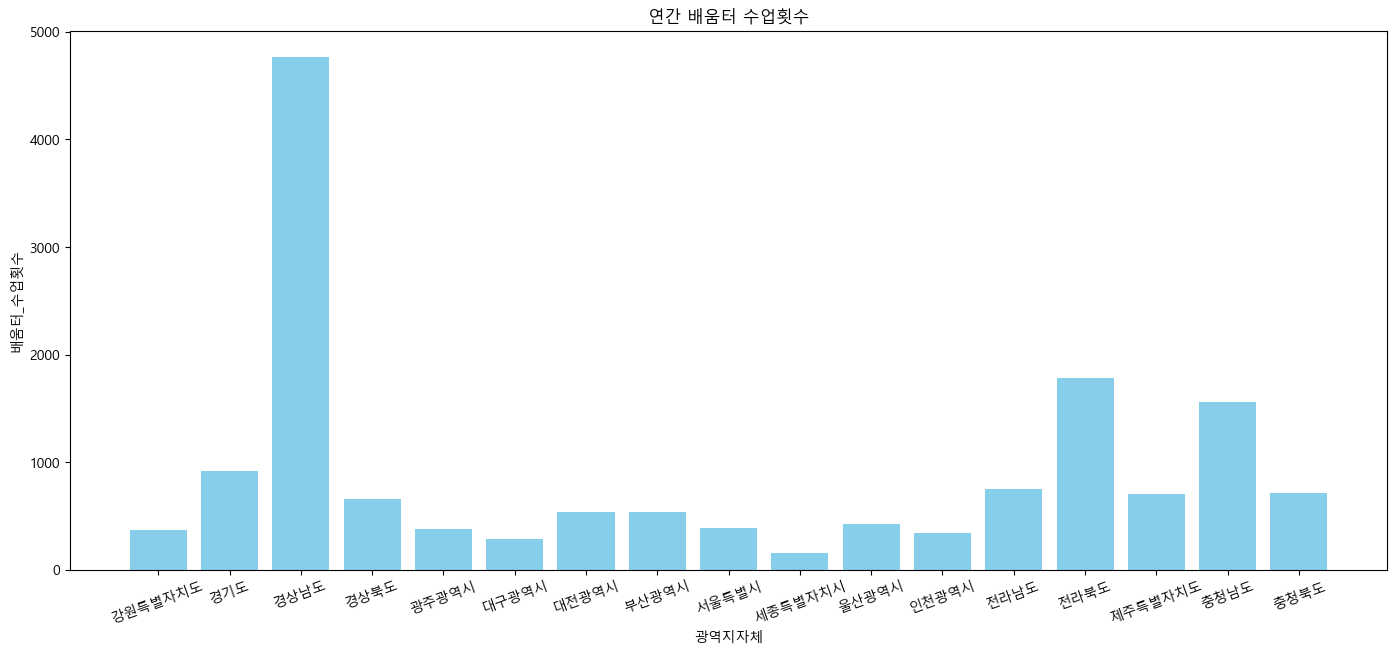

In [23]:
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic') # 한글 깨지는거 방지
plt.rcParams['axes.unicode_minus'] = False # 음수 기호 깨지는거 방지

plt.figure(figsize=(17,7))

plt.bar(final_result['광역지자체'], final_result['배움터_수업횟수'], color = 'skyblue')

plt.title('연간 배움터 수업횟수')
plt.xlabel('광역지자체')
plt.ylabel('배움터_수업횟수')

plt.xticks(rotation = 20)

plt.show()